### Import Dependencies

In [123]:
from google import genai
from google.genai import types
import pandas as pd
import cohere
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from qdrant_client import QdrantClient
from qdrant_client import models
from qdrant_client.http.models import  VectorParams, Distance, SparseVectorParams, Modifier, PayloadSchemaType, PointStruct, Document, Prefetch, FusionQuery
from typing import Literal, Dict, Annotated, List, Any
import random
from operator import add
from jinja2 import Template
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.prebuilt import ToolNode
import instructor
from langsmith import traceable
from langsmith import get_current_run_tree
from langgraph.types import Send

In [2]:
qdrant_client = QdrantClient(url="http://localhost:6333")

In [ ]:
def get_embeddings(text, task_type="SEMANTIC_SIMILARITY", model="gemini-embedding-001"):
    result = gemini_client.models.embed_content(
        model=model,
        contents=text,
        config=types.EmbedContentConfig(task_type=task_type)
    )
    return result.embeddings[0].values


def retrieve_data(query, qdrant_client, k=5, hybrid_search=True):
    query_embedding = get_embeddings(query)
    if hybrid_search:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            prefetch=[
                Prefetch(
                    query=query_embedding,
                    using="gemini-embedding-001",
                    limit=20
                ),
                Prefetch(
                    query=Document(
                        text=query,
                        model="qdrant/bm25"
                    ),
                    using="bm25",
                    limit=20
                )
            ],
            query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
            limit=k
        )
    else:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            query=query_embedding,
            using="gemini-embedding-001",
            limit=k
        )
    retrieved_context_ids=[]
    retrieved_context=[]
    similarity_scores=[]
    retrieved_context_ratings=[]

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    return {
        "retrieved_context_ids": retrieved_context_ids,
        "retrieved_context": retrieved_context,
        "similarity_scores": similarity_scores,
        "retrieved_context_ratings": retrieved_context_ratings
    }


def process_context(context):
    formatted_context = ""
    for id, chunk, rating in zip(context["retrieved_context_ids"], context["retrieved_context"], context["retrieved_context_ratings"]):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"
    return formatted_context

In [3]:
def get_embeddings(text, task_type="SEMANTIC_SIMILARITY", model="gemini-embedding-001"):
    result = gemini_client.models.embed_content(
        model=model,
        contents=text,
        config=types.EmbedContentConfig(task_type=task_type)
    )
    return result.embeddings[0].values

In [4]:
def retrieve_data(query, qdrant_client, k=5, hybrid_search=True):
    query_embedding = get_embeddings(query)
    if hybrid_search:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            prefetch=[
                Prefetch(
                    query=query_embedding,
                    using="gemini-embedding-001",
                    limit=20
                ),
                Prefetch(
                    query=Document(
                        text=query,
                        model="qdrant/bm25"
                    ),
                    using="bm25",
                    limit=20
                )
            ],
            query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
            limit=k
        )
    else:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            query=query_embedding,
            using="gemini-embedding-001",
            limit=k
        )
    retrieved_context_ids=[]
    retrieved_context=[]
    similarity_scores=[]
    retrieved_context_ratings=[]

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    return {
        "retrieved_context_ids": retrieved_context_ids,
        "retrieved_context": retrieved_context,
        "similarity_scores": similarity_scores,
        "retrieved_context_ratings": retrieved_context_ratings
    }

In [7]:
import os
gemini_client = genai.Client(api_key=os.getenv("GOOGLE_API_KEY"))

In [8]:
query = "Can I get a tablet"

In [9]:
answer =  retrieve_data(query, qdrant_client)

In [10]:
answer

{'retrieved_context_ids': ['B08DLWKXGL',
  'B0BHVH4D37',
  'B09WR36NK8',
  'B0BN58Z4YX',
  'B09RHF4L45'],
 'retrieved_context': ['Car Windshield Dashboard Tablet Holder for 5.5-12.9" Tablet Smartphone, EXSHOW Long Arm Suction Cup Car Window Tablet Cell Phone Mount for iPad Pro Air Mini, Samsung Galaxy Tab, iPhone, Xiaomi etc ',
  "7 inch Tablet, Android 11, 2GB RAM 32GB ROM, Quad-Core Processor, Dual Camera, WiFi, Bluetooth, 128GB Expand, Google Play GMS Certified 【Android 11, 2GB RAM+32GB ROM】 7 inch tablet use the latest Android 11.0 OS, 2GB RAM+32GB ROM, Can be expanded up to 512GB via TF card, ensures you have an ultra-smooth gaming and speedy multimedia using experience, delivering quick app launches 【Google GMS Certified】 The android tablet has passed the GMS certification and Pre-installed Google Play, You have full access to the latest Google service, such as Google Play, WhatsApp, G-mail, Skype, Disney+, Netflix, Twitter, YouTube, Tiktok, Google Assistant and more brilliant ap

## Multi-intent questions

In [11]:
query = "Can I get a tablet for me and some headphones for my son?"

In [12]:
answer =  retrieve_data(query, qdrant_client)

In [13]:
answer

{'retrieved_context_ids': ['B09XQMRYBJ',
  'B0BQLV7TSJ',
  'B09SZNLXJQ',
  'B09VBWBHBC',
  'B0BHKS1W55'],
 'retrieved_context': ['Kids Headphones with Mic, Share Port, Foldable Stereo On-Ear Kids Headset, 91dB Volume Limited, Adjustable Headband Headphones for Kids Teens Adults, School Headphones for iPad Tablet, Pink & Green 🎵 [ ADJUSTABLE BAND ] No matter what his/her head size is, an adjustable headband and over-ear design can bring more possibilities. It is not only suitable for your children, but also for teenagers. 🎵 [ IMMERSE IN THE MUSIC ] There’s a volume Limited of 94dB, there’s zero fear of sonic overload, to prevent damage to young lugholes. Enjoy these kids headphones, your child will get rich bass and lifelike audio. 🎵[ THE SOFT, SNUG PAD & FLEXIBLE ENOUGH ] The enlarged, thickened pivoting ear cushion with good breathability can block out most outside noises. In addition, Lightweight headphones for kids for Prolonged Wearing and ensuring lasting comfort. 🎵 [ FOR VERSATIL

In [21]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

In [99]:
def query_expansion_node(query) -> dict:
    prompt_template = """You are a query expansion module in a shoping assistant. Your job is to rewrite a customer's query into distinct statements.

    ## Instructions
    - You must expand the user's query into 1-5 distinct concise statements.
    - Each statement should captue a separate product or attribute from the original query.
    - Use natural product-description language
    - Do not produce multiple statements that express the same intent.

    ##Examples

    Question "Can I get earphones for me and a waterproof speaker?"
    Statements:
    - "Earphones"
    - "Waterproof speaker"

    Question "Do you have any toys?"
    Statements:
    - "Toys"

    Question "I want to buy a warm jacket for hiking"
    Statements:
    - "Insulated winter jacket"
    - "Hiking outerwear for cold weather"
    
    ## User Query

    {{ query }}
    """
    template = Template(prompt_template)
    prompt = template.render(query=query)
    client = instructor.from_genai(
    gemini_client,
    model="gemini-3.1-flash-lite"
    )
    response, raw_response = client.create_with_completion(
    messages=[
        {"role": "user", "content": prompt}
    ],
    response_model=QueryExpandResponse,
    )

    return {
        "queries": response.statements
    }

    

In [100]:
answer = query_expansion_node(query)

In [97]:
query

'Can I get a tablet for me and some headphones for my son?'

In [101]:
answer

{'queries': ['Tablet', 'Headphones for children']}

### LangGraph

#### Query Expansion

In [102]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[list[str], add] = []
    initial_query: str = ""
    answer: str = ""

In [103]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

In [104]:
@traceable(
    name="query_expansion",
    run_type="llm",
    metadata={
        "ls_provider": "google",
        "ls_model_name": "gemini-3.1-flash-lite"
    }
)
def query_expansion_node(state: State) -> dict:
    prompt_template = """You are a query expansion module in a shoping assistant. Your job is to rewrite a customer's query into distinct statements.

    ## Instructions
    - You must expand the user's query into 1-5 distinct concise statements.
    - Each statement should captue a separate product or attribute from the original query.
    - Use natural product-description language
    - Do not produce multiple statements that express the same intent.

    ##Examples

    Question "Can I get earphones for me and a waterproof speaker?"
    Statements:
    - "Earphones"
    - "Waterproof speaker"

    Question "Do you have any toys?"
    Statements:
    - "Toys"

    Question "I want to buy a warm jacket for hiking"
    Statements:
    - "Insulated winter jacket"
    - "Hiking outerwear for cold weather"
    
    ## User Query

    {{ query }}
    """
    template = Template(prompt_template)
    prompt = template.render(query=state.initial_query)
    client = instructor.from_genai(
    gemini_client,
    model="gemini-3.1-flash-lite"
    )
    response, raw_response = client.create_with_completion(
    messages=[
        {"role": "user", "content": prompt}
    ],
    response_model=QueryExpandResponse,
    )

    return {
        "expanded_query": response.statements
    }

    

In [105]:
### Retriever Node

@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={
        "ls_provider": "google",
        "ls_model_name": "gemini-embedding-001",
    }
)
def get_embeddings(text, task_type="SEMANTIC_SIMILARITY", model="gemini-embedding-001"):
    result = gemini_client.models.embed_content(
        model=model,
        contents=text,
        config=types.EmbedContentConfig(task_type=task_type)
    )
    return result.embeddings[0].values

@traceable(
    name="retrieve_data",
    run_type="retriever"
)
def retrieve_data(query, qdrant_client, k=5, hybrid_search=True):
    query_embedding = get_embeddings(query)
    if hybrid_search:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            prefetch=[
                Prefetch(
                    query=query_embedding,
                    using="gemini-embedding-001",
                    limit=20
                ),
                Prefetch(
                    query=Document(
                        text=query,
                        model="qdrant/bm25"
                    ),
                    using="bm25",
                    limit=20
                )
            ],
            query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
            limit=k
        )
    else:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            query=query_embedding,
            using="gemini-embedding-001",
            limit=k
        )
    retrieved_context_ids=[]
    retrieved_context=[]
    similarity_scores=[]
    retrieved_context_ratings=[]

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    formatted_context = ""
    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return formatted_context

@traceable(
    name="retriever_node",
    run_type="retriever"
)
def retriever_node(state: State) -> dict:

    qdrant_client = QdrantClient(url="http://localhost:6333")
    retrieved_context = []
    for query in state.expanded_query:
        retrieved_context.append(retrieve_data(query, qdrant_client))
    return {
        "retrieved_context": retrieved_context
    }

## Aggregator Node

In [106]:
class AggregatorResponse(BaseModel):
    answer: str

In [113]:
@traceable(
    name="generate_answer",
    run_type="llm",
    metadata={
        "ls_provider": "google",
        "ls_model_name": "gemini-3.1-flash-lite"
    }
)
def aggregator_node(state: State) -> dict:

    preprocessed_context = "\n".join(state.retrieved_context)
    

    prompt_template = """You are a shopping assistant that can answer questions about the products in stock.

    you will be given a question and a list of context.

    ## Instructions
    - You Need to answer the question based on the provided context only.
    - Never use word context and refer to it as the available products.
    - The answer to the question should contain detailed information about the product and returned with detailed specifications in bullet points.

    ## Context
    {{ preprocessed_context }}

    ## Question
    {{ question }}
    """
    template = Template(prompt_template)
    prompt = template.render(question=state.initial_query, preprocessed_context=preprocessed_context)
    client = instructor.from_genai(
    gemini_client,
    model="gemini-3.1-flash-lite"
    )
    response, raw_response = client.create_with_completion(
    messages=[
        {"role": "user", "content": prompt}
    ],
    response_model=AggregatorResponse,
    )

    return {
        "answer": response.answer
    }

In [114]:
workflow = StateGraph(State)

workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)


workflow.add_edge(START, "query_expansion_node")
workflow.add_edge("query_expansion_node", "retriever_node")
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)
graph = workflow.compile()

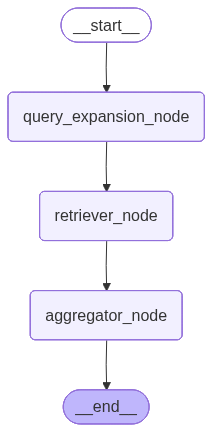

In [90]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [115]:
query = "Can I get a tablet for me and some headphones for my son?"

In [116]:
initial_state = {
    "initial_query": query
}

In [117]:
result = graph.invoke(initial_state)

In [118]:
result

{'expanded_query': ['Tablet', 'Headphones for children'],
 'retrieved_context': ['- ID: B09RN3KN5C, rating: 4.3, description: Pad \n- ID: B08DLWKXGL, rating: 4.0, description: Car Windshield Dashboard Tablet Holder for 5.5-12.9" Tablet Smartphone, EXSHOW Long Arm Suction Cup Car Window Tablet Cell Phone Mount for iPad Pro Air Mini, Samsung Galaxy Tab, iPhone, Xiaomi etc \n- ID: B0BFGHH4QL, rating: 4.8, description: Choco Mocha 12.5 Inch Kids Tablet Sleeve Bag 12.5 X 9.8 X 1.3 inches About Compatibility: Fits all standard tablets up to 10", whether e-readers, Amazon tablets (Fire Kids Edition 7, Fire HD 8, Fire 7, Fire 10 ) or Amazon Kindle‘s. Carrying Method: crossbody/handle Tablet sleeve built-in protective layer, strong protection,with a soft inner lining offers maximum protection against scratches Multiple pockets for tablet accessories, headphones or charging cables, etc\n- ID: B0B6ZZH83Y, rating: 4.1, description: iFongsh Tablet Stand Tripod, 80\'\' Tablet Stand Floor, Adjustable

In [119]:
print(result["answer"])

Yes, you can certainly purchase both a tablet and headphones from the available products. Here are the details for the options you can choose from:

### Tablet Options

**MERRYROYAL Android 11 Tablet (ID: B09WR36NK8)**
*   **Rating:** 3.9
*   **Display:** 10.4-inch HD (1332x800 resolution)
*   **Performance:** Quad-core processor with 2GB RAM and 32GB ROM
*   **Storage:** microSD card slot for expansion up to 128GB
*   **Battery:** 6000mAh battery providing up to 5 hours of usage
*   **Design:** Ultra-narrow 8.9mm bezel
*   **Included:** USB Type-C data cable
*   **Warranty:** 1-year return service

---

### Kids Headphones Options

**Voopwink Kids Headphones (ID: B09LTX3SQX)**
*   **Rating:** 4.5
*   **Key Features:** Wired with HD microphone, 85dB/94dB volume limit switch, 40mm audio driver for stereo sound, foldable design, padded cushions.
*   **Compatibility:** Standard 3.5mm audio jack.

**JevZoise Kids Headphones (ID: B09SZNLXJQ)**
*   **Rating:** 4.4
*   **Key Features:** Wired

#### Query Expansion w/ parallel execution

In [134]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[list[str], add] = []
    initial_query: str = ""
    answer: str = ""
    query : str = ""
    k : int = 10

In [148]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

In [136]:
@traceable(
    name="query_expansion",
    run_type="llm",
    metadata={
        "ls_provider": "google",
        "ls_model_name": "gemini-3.1-flash-lite"
    }
)
def query_expansion_node(state: State) -> dict:
    prompt_template = """You are a query expansion module in a shoping assistant. Your job is to rewrite a customer's query into distinct statements.

    ## Instructions
    - You must expand the user's query into 1-5 distinct concise statements.
    - Each statement should captue a separate product or attribute from the original query.
    - Use natural product-description language
    - Do not produce multiple statements that express the same intent.

    ##Examples

    Question "Can I get earphones for me and a waterproof speaker?"
    Statements:
    - "Earphones"
    - "Waterproof speaker"

    Question "Do you have any toys?"
    Statements:
    - "Toys"

    Question "I want to buy a warm jacket for hiking"
    Statements:
    - "Insulated winter jacket"
    - "Hiking outerwear for cold weather"
    
    ## User Query

    {{ query }}
    """
    template = Template(prompt_template)
    prompt = template.render(query=state.initial_query)
    client = instructor.from_genai(
    gemini_client,
    model="gemini-3.1-flash-lite"
    )
    response, raw_response = client.create_with_completion(
    messages=[
        {"role": "user", "content": prompt}
    ],
    response_model=QueryExpandResponse,
    )

    return {
        "expanded_query": response.statements
    }

In [137]:
def query_expand_conditional_edges(state: State) -> dict:

    send_messages = []
    for query in state.expanded_query:
        send_messages.append(
            Send(
                "retriever_node",
                {
                    "query": query,
                    "k": state.k
                }
            )
        )
    return send_messages
        

In [138]:
### Retriever Node

@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={
        "ls_provider": "google",
        "ls_model_name": "gemini-embedding-001",
    }
)
def get_embeddings(text, task_type="SEMANTIC_SIMILARITY", model="gemini-embedding-001"):
    result = gemini_client.models.embed_content(
        model=model,
        contents=text,
        config=types.EmbedContentConfig(task_type=task_type)
    )
    return result.embeddings[0].values

@traceable(
    name="retrieve_data",
    run_type="retriever"
)
def retriever_node(state: State) -> dict:
    qdrant_client = QdrantClient(url="http://localhost:6333")
    hybrid_search = True
    query_embedding = get_embeddings(state["query"])
    if hybrid_search:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            prefetch=[
                Prefetch(
                    query=query_embedding,
                    using="gemini-embedding-001",
                    limit=20
                ),
                Prefetch(
                    query=Document(
                        text=query,
                        model="qdrant/bm25"
                    ),
                    using="bm25",
                    limit=20
                )
            ],
            query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
            limit=state["k"]
        )
    else:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            query=query_embedding,
            using="gemini-embedding-001",
            limit=state["k"]
        )
    retrieved_context_ids=[]
    retrieved_context=[]
    similarity_scores=[]
    retrieved_context_ratings=[]

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    formatted_context = ""
    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return {
        "retrieved_context": [formatted_context]
    }

## Aggregator Node

In [139]:
class AggregatorResponse(BaseModel):
    answer: str

In [140]:
@traceable(
    name="generate_answer",
    run_type="llm",
    metadata={
        "ls_provider": "google",
        "ls_model_name": "gemini-3.1-flash-lite"
    }
)
def aggregator_node(state: State) -> dict:

    preprocessed_context = "\n".join(state.retrieved_context)
    

    prompt_template = """You are a shopping assistant that can answer questions about the products in stock.

    you will be given a question and a list of context.

    ## Instructions
    - You Need to answer the question based on the provided context only.
    - Never use word context and refer to it as the available products.
    - The answer to the question should contain detailed information about the product and returned with detailed specifications in bullet points.

    ## Context
    {{ preprocessed_context }}

    ## Question
    {{ question }}
    """
    template = Template(prompt_template)
    prompt = template.render(question=state.initial_query, preprocessed_context=preprocessed_context)
    client = instructor.from_genai(
    gemini_client,
    model="gemini-3.1-flash-lite"
    )
    response, raw_response = client.create_with_completion(
    messages=[
        {"role": "user", "content": prompt}
    ],
    response_model=AggregatorResponse,
    )

    return {
        "answer": response.answer
    }

In [141]:
workflow = StateGraph(State)

workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)

workflow.add_conditional_edges(
    "query_expansion_node",
    query_expand_conditional_edges,
)


workflow.add_edge(START, "query_expansion_node")
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)
graph = workflow.compile()

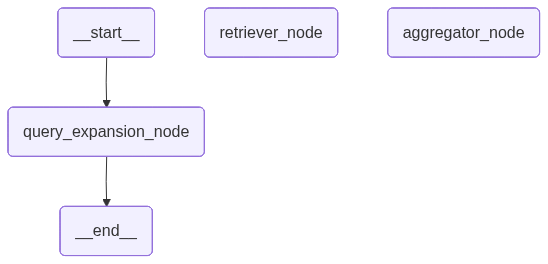

In [142]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [143]:
query = "Can I get a tablet for me and some headphones for my son?"

In [144]:
initial_state = {
    "initial_query": query
}

In [145]:
result = graph.invoke(initial_state)

In [146]:
result

{'expanded_query': ['Tablet', 'Headphones for a child'],
 'retrieved_context': ['- ID: B09RN3KN5C, rating: 4.3, description: Pad \n- ID: B08DLWKXGL, rating: 4.0, description: Car Windshield Dashboard Tablet Holder for 5.5-12.9" Tablet Smartphone, EXSHOW Long Arm Suction Cup Car Window Tablet Cell Phone Mount for iPad Pro Air Mini, Samsung Galaxy Tab, iPhone, Xiaomi etc \n- ID: B0BFGHH4QL, rating: 4.8, description: Choco Mocha 12.5 Inch Kids Tablet Sleeve Bag 12.5 X 9.8 X 1.3 inches About Compatibility: Fits all standard tablets up to 10", whether e-readers, Amazon tablets (Fire Kids Edition 7, Fire HD 8, Fire 7, Fire 10 ) or Amazon Kindle‘s. Carrying Method: crossbody/handle Tablet sleeve built-in protective layer, strong protection,with a soft inner lining offers maximum protection against scratches Multiple pockets for tablet accessories, headphones or charging cables, etc\n- ID: B09XQMRYBJ, rating: 4.5, description: Kids Headphones with Mic, Share Port, Foldable Stereo On-Ear Kids H

In [147]:
print(result["answer"])

Yes, we have several options available for both tablets and headphones in our inventory.

### Available Tablets
*   **Lenovo Tab M10 Plus 3rd Gen Tablet (ID: B0C5QQDN3T)**
    *   **Rating:** 4.2
    *   **Display:** 10.6" FHD IPS display with up to 1080p resolution.
    *   **System:** Android 12.
    *   **Storage:** 32GB.
    *   **Features:** Quad speaker system with Dolby Atmos, lightweight and portable design, Immersive Reading Mode, and long-lasting battery life.
*   **MERRYROYAL Tablet (ID: B09WR36NK8)**
    *   **Rating:** 3.9
    *   **Display:** 10.4-inch HD display (1332x800).
    *   **System:** Android 11 Go.
    *   **Storage:** 2GB RAM / 32GB ROM (expandable up to 128GB via microSD).
    *   **Features:** Slim 8.9mm bezel design, 6000mAh battery (up to 5 hours of use), and includes a USB Type-C data cable.

### Available Kids Headphones
*   **Kids Headphones with Mic (ID: B09XQMRYBJ)**
    *   **Rating:** 4.5
    *   **Features:** Foldable, adjustable headband, 91dB vol